# Análisis Geoespacial IPM - Zona de Estudio: Roosevelt

Este notebook prioriza la visualización cartográfica de las 5 variables más relevantes del Índice de Pobreza Multidimensional (IPM) en el corredor Roosevelt (Buffer 100m).

**Características:**
- Mapa base con delimitación de manzanas.
- Etiquetas de valores dentro de cada manzana.
- Paleta de colores accesible para personas daltónicas (Viridis).
- Leyenda de categorías basada en la incidencia.

In [22]:
# 1. Instalación de dependencias (solo en Colab)
import sys
if 'google.colab' in sys.modules:
    !pip install geopandas matplotlib seaborn -q

In [23]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style('white')
print('Librerías listas')

Librerías listas


In [24]:
# 2. Clonar o actualizar repositorio (solo Colab)
import sys
REPO_URL = 'https://github.com/j0rg3c45/Pobreza_multidimensional_y_condicion_social.git'
REPO_DIR = 'Pobreza_multidimensional_y_condicion_social'

if 'google.colab' in sys.modules:
    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL}
    else:
        !cd {REPO_DIR} && git pull
    print('Repositorio listo')

# 3. Definir rutas base
DATA_BASE = '../data' if os.path.exists('../data') else os.path.join(REPO_DIR, 'indice_Pobreza/data')

# Capa principal: manzanas IPM con variables (zona de estudio)
PATH_IPM_VARS = os.path.join(DATA_BASE, 'Geojson_Roosevelt/geojson_filtrado_tramos_Roosevelt_Buffer_100/Mzn_ipm_variables_filtrado_tramos_Roosevelt_Buffer_100.geojson')
# Capa de fondo: todas las manzanas ICS de Cali
PATH_MANZANAS_FONDO = os.path.join(DATA_BASE, 'geojosn_ICS/ics_mzn.geojson')
# Polígono del área de estudio (buffer Roosevelt)
PATH_AREA_ESTUDIO = os.path.join(DATA_BASE, 'Geojson_Roosevelt/tramos_Roosevelt_Buffer_100.geojson')

# Cargar capas
gdf = gpd.read_file(PATH_IPM_VARS)
gdf_fondo = gpd.read_file(PATH_MANZANAS_FONDO)
gdf_area = gpd.read_file(PATH_AREA_ESTUDIO)

# Unificar CRS
crs_base = gdf.crs
gdf_fondo = gdf_fondo.to_crs(crs_base)
gdf_area = gdf_area.to_crs(crs_base)

print(f'Datos cargados: {len(gdf)} manzanas en zona de estudio')
print(f'Fondo: {len(gdf_fondo)} manzanas de contexto')
print(f'Área de estudio: {len(gdf_area)} polígonos de buffer')

remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 10 (delta 7), reused 7 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (10/10), 715.32 KiB | 3.58 MiB/s, done.
From https://github.com/j0rg3c45/Pobreza_multidimensional_y_condicion_social
   dcac571..6438113  main       -> origin/main
Updating dcac571..6438113
Fast-forward
 .../notebooks_py/04_mapeo_ipm_roosevelt.ipynb      | 198 ++++++++++++++++-----
 1 file changed, 154 insertions(+), 44 deletions(-)
Repositorio listo
Datos cargados: 40 manzanas


In [25]:
# 3. Identificación de las 15 variables y selección de las Top 5
variables_ipm = [
    'ANALF_', 'BAJO_', 'INFANCIA_', 'INASIS_', 'REZAGO_',
    'TRAB_INFAN', 'DEPEN_', 'INFOR_', 'SALUD_', 'ASEGU_',
    'HACI_', 'PARED_', 'EXCRE_', 'PISOS_', 'AGUA_'
]

# Diccionario para nombres legibles
diccionario_nombres = {
    'ANALF_': 'Analfabetismo', 'BAJO_': 'Bajo Logro Educativo', 'INFANCIA_': 'Barreras Infancia',
    'INASIS_': 'Inasistencia Escolar', 'REZAGO_': 'Rezago Escolar', 'TRAB_INFAN': 'Trabajo Infantil',
    'DEPEN_': 'Dependencia Económica', 'INFOR_': 'Informalidad', 'SALUD_': 'Sin Aseguramiento Salud',
    'ASEGU_': 'Barreras Salud', 'HACI_': 'Hacinamiento Crítico', 'PARED_': 'Paredes Inadecuadas',
    'EXCRE_': 'Excretas Inadecuadas', 'PISOS_': 'Pisos Inadecuados', 'AGUA_': 'Sin Agua Mejorada'
}

# Calcular promedio local para elegir las 5 más relevantes (mayor incidencia)
top_5 = gdf[variables_ipm].mean().sort_values(ascending=False).head(5).index.tolist()
print('Las 5 variables con mayor incidencia en Roosevelt son:')
for v in top_5:
    print(f'- {diccionario_nombres[v]} ({v})')

Las 5 variables con mayor incidencia en Roosevelt son:
- Informalidad (INFOR_)
- Barreras Salud (ASEGU_)
- Dependencia Económica (DEPEN_)
- Bajo Logro Educativo (BAJO_)
- Rezago Escolar (REZAGO_)


In [26]:
# 4. Función de mapeo con escala semántica accesible (daltonismo)
from matplotlib.patheffects import withStroke
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import numpy as np
import re

# Escala semántica (8 categorías de intensidad)
CATEGORIAS = [
    'Bajo', 'Moderado-Bajo', 'Moderado', 'Moderado-Alto',
    'Alto', 'Muy Alto', 'Extremo', 'Extremo Máximo'
]

# Paleta accesible para daltonismo: cividis discretizado en 8 niveles
_cividis = plt.get_cmap('cividis', 8)
COLORES_ACCESIBLES = [_cividis(i) for i in range(8)]

# Proporciones de corte para escalar al ref_max de cada indicador
PROPORCIONES_CORTE = [0.0, 0.06, 0.08, 0.10, 0.12, 0.15, 0.18, 0.24, 1.0]

# ref_max por variable (del contexto metodológico)
REF_MAX_VARS = {
    'INFOR_': 100, 'BAJO_': 80, 'DEPEN_': 80, 'REZAGO_': 60, 'ASEGU_': 50,
    'SALUD_': 40, 'ANALF_': 40, 'HACI_': 40, 'INASIS_': 30, 'INFANCIA_': 30,
    'AGUA_': 20, 'TRAB_INFAN': 20, 'EXCRE_': 20, 'PARED_': 20, 'PISOS_': 20
}

def get_boundaries(column):
    """Calcula los límites de categoría escalados al ref_max del indicador."""
    ref_max = REF_MAX_VARS.get(column, 100)
    return [p * ref_max for p in PROPORCIONES_CORTE]

def limpiar_titulo(titulo):
    """Elimina texto entre paréntesis relacionado con paletas/accesibilidad."""
    return re.sub(r'\s*\([^)]*(?:paleta|accesible|daltonismo|cividis)[^)]*\)', '', titulo, flags=re.IGNORECASE).strip()

def plot_ipm_variable(gdf, gdf_fondo, gdf_area, column, title):
    """Genera mapa con fondo de manzanas, polígono de área de estudio y datos IPM."""
    fig, ax = plt.subplots(1, 1, figsize=(18, 12))
    
    # --- Capa 1: Fondo de manzanas (contexto, gris muy claro) ---
    # Recortar fondo al extent del área de estudio con margen
    bounds = gdf_area.total_bounds  # [minx, miny, maxx, maxy]
    margen = 0.005  # ~500m de margen en grados
    extent = [bounds[0] - margen, bounds[1] - margen, bounds[2] + margen, bounds[3] + margen]
    fondo_clip = gdf_fondo.cx[extent[0]:extent[2], extent[1]:extent[3]]
    
    fondo_clip.plot(ax=ax, facecolor='#F0F0F0', edgecolor='#CCCCCC', linewidth=0.3, alpha=0.7)
    
    # --- Capa 2: Polígono del área de estudio (destacado) ---
    gdf_area.plot(ax=ax, facecolor='none', edgecolor='#E63946', linewidth=2.5, linestyle='--', zorder=2)
    
    # --- Capa 3: Manzanas con datos IPM (escala semántica) ---
    boundaries = get_boundaries(column)
    cmap = ListedColormap(COLORES_ACCESIBLES)
    norm = BoundaryNorm(boundaries, cmap.N)
    
    gdf.plot(column=column,
             cmap=cmap,
             norm=norm,
             edgecolor='black',
             linewidth=0.6,
             alpha=0.95,
             ax=ax,
             zorder=3)
    
    # --- Etiquetas de valor dentro de cada manzana ---
    for x, y, label in zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y, gdf[column]):
        if label > 0:
            ax.annotate(f'{label:.1f}',
                        xy=(x, y),
                        xytext=(0, 0),
                        textcoords='offset points',
                        ha='center',
                        fontsize=8,
                        fontweight='bold',
                        color='white',
                        path_effects=[withStroke(linewidth=2, foreground='black')],
                        zorder=4)
    
    # --- Leyenda (fuera del mapa, a la derecha) ---
    legend_patches = []
    for i, cat in enumerate(CATEGORIAS):
        rango_min = boundaries[i]
        rango_max = boundaries[i + 1]
        label = f'{cat} ({rango_min:.1f} - {rango_max:.1f}%)'
        legend_patches.append(mpatches.Patch(color=COLORES_ACCESIBLES[i], label=label))
    # Agregar entrada para el área de estudio
    legend_patches.append(mpatches.Patch(facecolor='none', edgecolor='#E63946', linewidth=2, linestyle='--', label='Área de estudio (Buffer 100m)'))
    
    ax.legend(handles=legend_patches,
              title=f'% Hogares con {title}',
              loc='center left',
              bbox_to_anchor=(1.02, 0.5),
              fontsize=9,
              title_fontsize=10,
              framealpha=0.95,
              borderaxespad=0)
    
    # --- Título limpio (sin texto de paleta/accesibilidad) ---
    titulo = limpiar_titulo(f'Incidencia de {title} - Roosevelt')
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    
    # Ajustar extent al área de estudio + margen
    ax.set_xlim(extent[0], extent[2])
    ax.set_ylim(extent[1], extent[3])
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1962/2107979780.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _cividis = cm.get_cmap('cividis', 8)


/tmp/ipykernel_1962/2107979780.py:66: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y, gdf[column]):


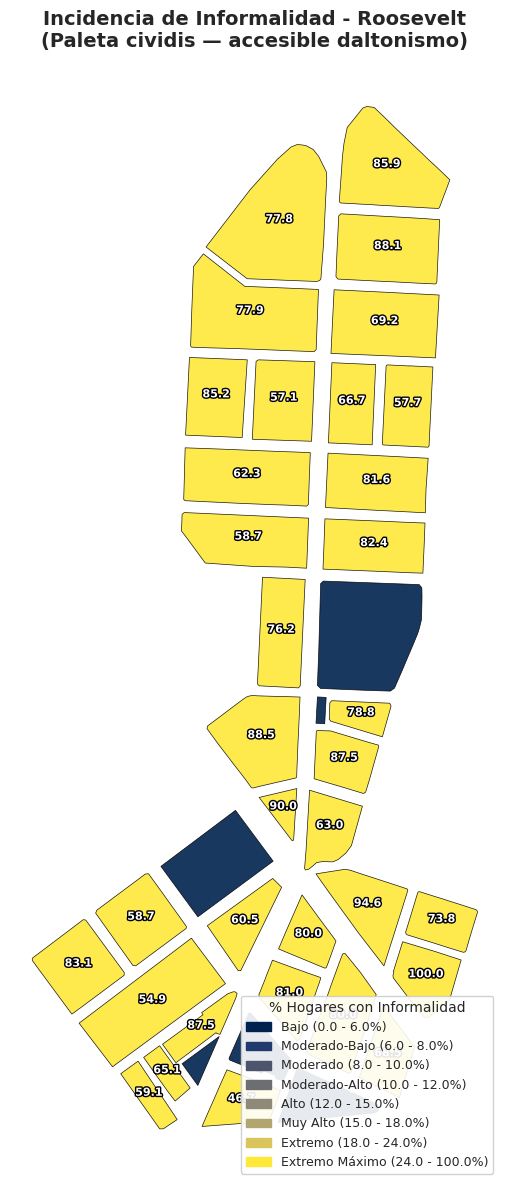

/tmp/ipykernel_1962/2107979780.py:66: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y, gdf[column]):


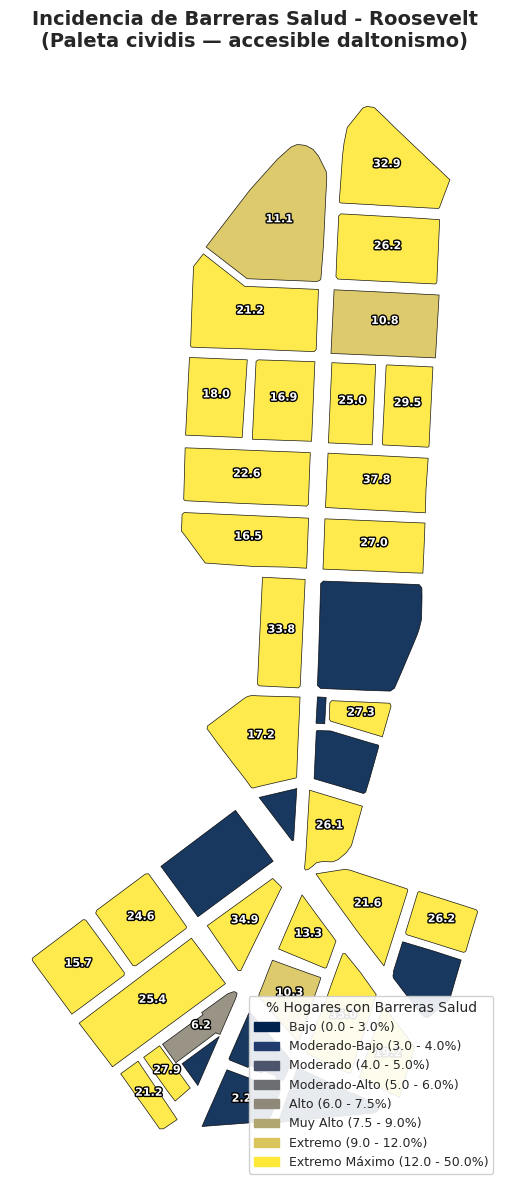

/tmp/ipykernel_1962/2107979780.py:66: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y, gdf[column]):


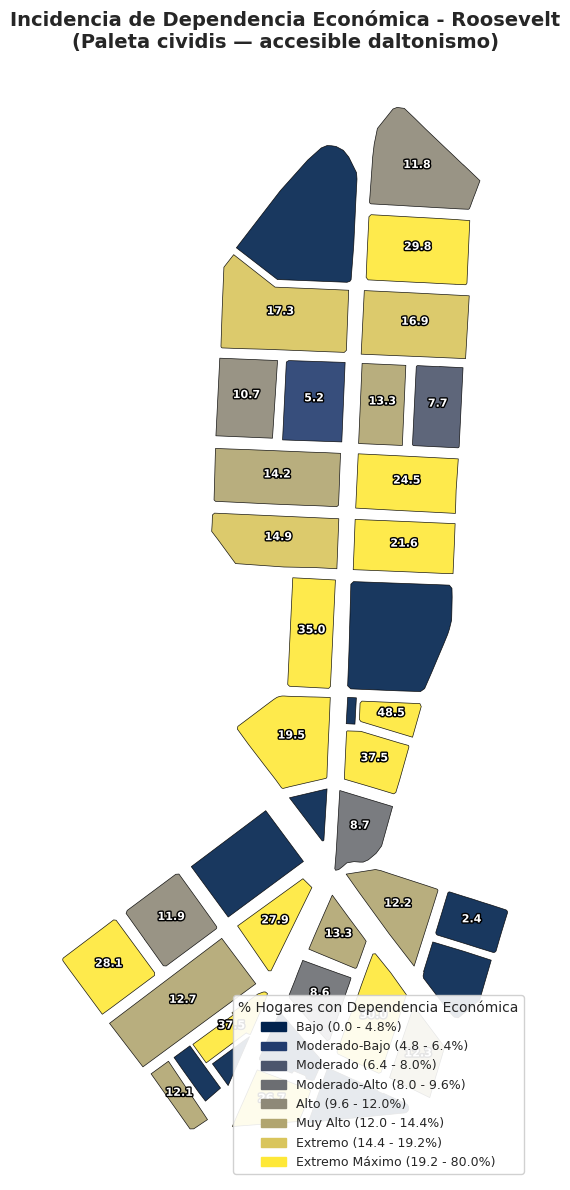

/tmp/ipykernel_1962/2107979780.py:66: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y, gdf[column]):


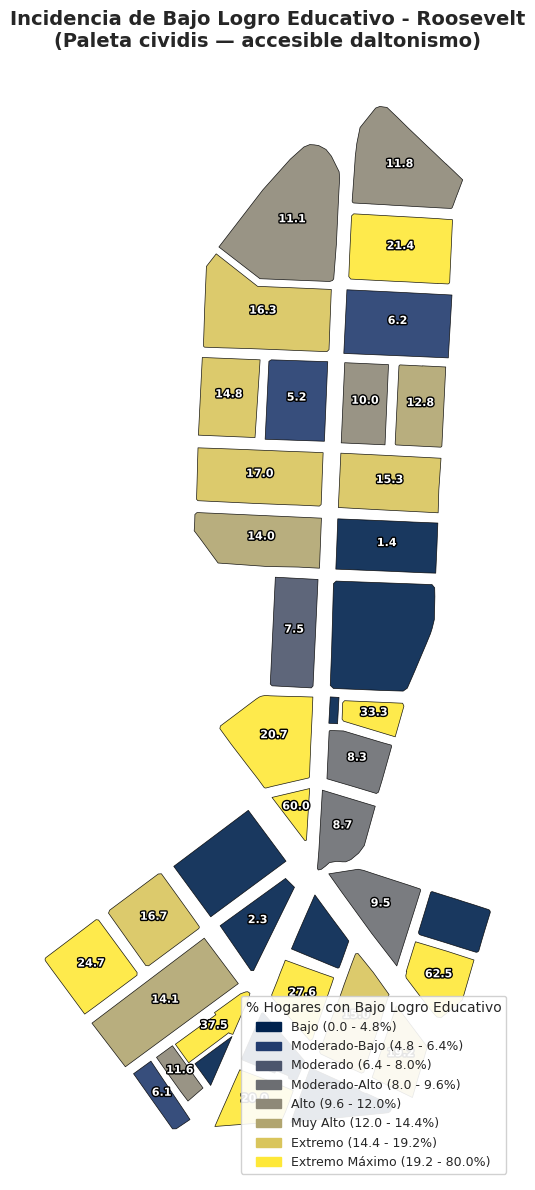

/tmp/ipykernel_1962/2107979780.py:66: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y, gdf[column]):


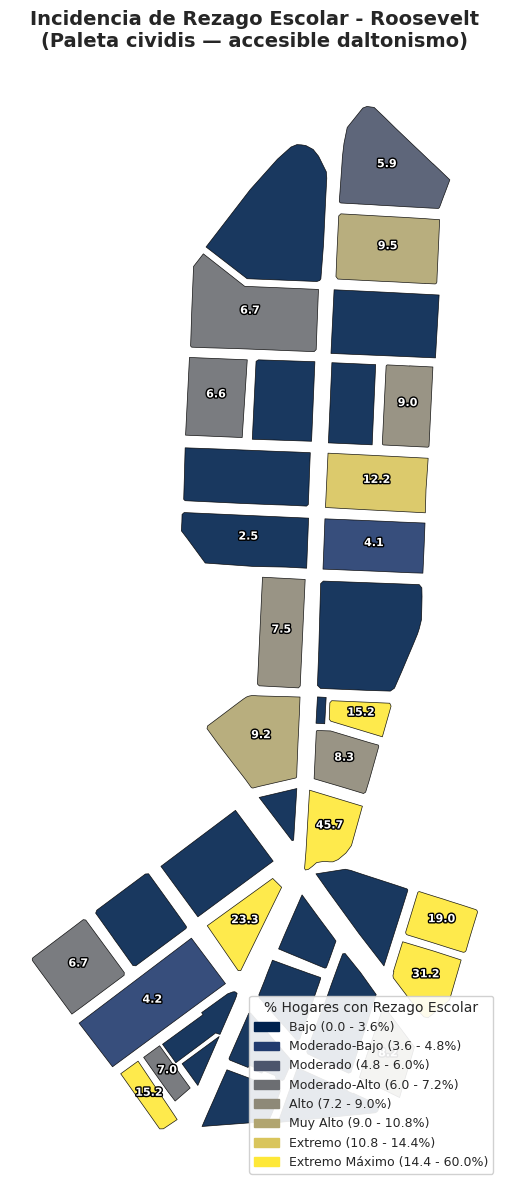

In [27]:
# 5. Generar los 5 mapas prioritarios
for var in top_5:
    plot_ipm_variable(gdf, gdf_fondo, gdf_area, var, diccionario_nombres[var])